In [1]:
import numpy as np
import matplotlib.pyplot as plt
from qcodes import Station, Measurement, initialise_or_create_database_at, new_experiment
import time
import random
from tqdm import tqdm

# Import our mock instruments
from qcodes.instrument_drivers.mock_instruments import MockDAC, MockField, MockLockin   

In [2]:
# Initialize the database
initialise_or_create_database_at("./experiment_data.db")

# Create a new experiment
new_experiment(name="Mock Field Sweep", sample_name="Mock Sample")


station = Station()
dac = MockDAC('dac', num_channels=4)
field = MockField('field')
lockin = MockLockin('lockin')

station.add_component(dac)
station.add_component(field)
station.add_component(lockin)

There is (are) already experiment(s) with the name of Mock Field Sweep and sample name of Mock Sample in the database.


'lockin'

In [3]:
# Set up initial conditions
dac.ch01.voltage(0.1)
dac.ch02.voltage(-0.1)
field.field(0)
lockin.frequency(133)
lockin.amplitude(0.1)

# Create a measurement
meas = Measurement()

# Register parameters
meas.register_parameter(field.field)
meas.register_parameter(lockin.X, setpoints=(field.field,))
meas.register_parameter(lockin.Y, setpoints=(field.field,))

In [4]:
meas = Measurement()
meas.register_parameter(field.field)
meas.register_parameter(lockin.X, setpoints=(field.field,))
meas.register_parameter(lockin.Y, setpoints=(field.field,))

Starting experimental run with id: 9. 


augmenting the field value: 100%|██████████| 101/101 [00:10<00:00,  9.48it/s]


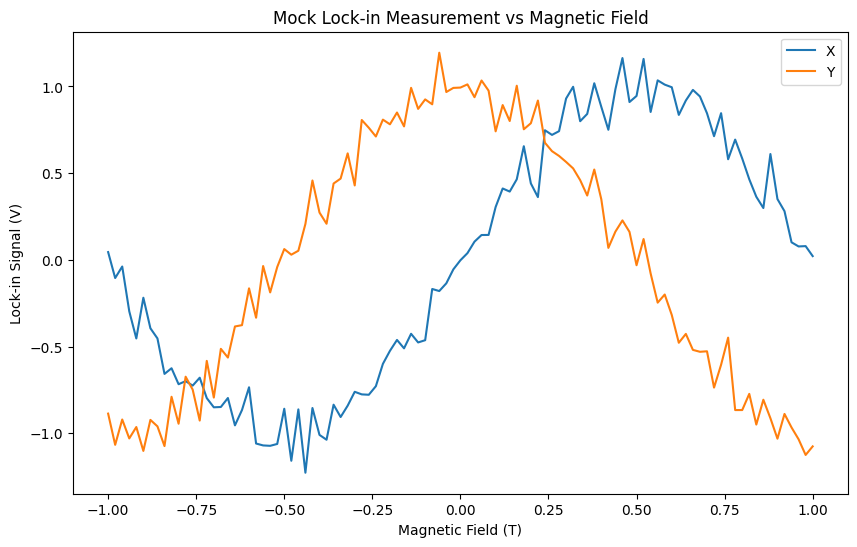

Final DAC voltages: CH1 = 0.1, CH2 = -0.1
Final magnetic field: 0.0
Final lock-in settings: f = 133, A = 0.1


In [5]:
fields = np.linspace(-1, 1, 101)
X_data = []
Y_data = []

# Run the experiment
with meas.run() as datasaver:
    for b in tqdm(fields, desc='augmenting the field value'):

        time.sleep(0.1)  # Small delay to simulate field ramping
        
        X = np.sin(b * np.pi) + random.gauss(0, 0.1)
        Y = np.cos(b * np.pi) + random.gauss(0, 0.1)

        datasaver.add_result((field.field, b),
                                (lockin.X, X),
                                (lockin.Y, Y))
        X_data.append(X)
        Y_data.append(Y)

# Plot the results
plt.figure(figsize=(10,6))
plt.plot(fields, X_data, label='X')
plt.plot(fields, Y_data, label='Y')
plt.xlabel('Magnetic Field (T)')
plt.ylabel('Lock-in Signal (V)')
plt.legend()
plt.title('Mock Lock-in Measurement vs Magnetic Field')
plt.show()

# Print final instrument states
print(f"Final DAC voltages: CH1 = {dac.ch01.voltage()}, CH2 = {dac.ch02.voltage()}")
print(f"Final magnetic field: {field.field()}")
print(f"Final lock-in settings: f = {lockin.frequency()}, A = {lockin.amplitude()}")

In [1]:
import numpy as np
from qcodes.instrument_drivers.mock_instruments import DummyBase
from qcodes.parameters import Parameter
from qcodes.utils.validators import Numbers

class MockKeithley6517A(DummyBase):
    def __init__(self, name, **kwargs):
        super().__init__(name, **kwargs)

        self._voltage = 0
        self._current = 0
        # self._resistance = 1e6  # 1 MOhm default resistance
        self._resistance = 20e6  # 1 MOhm default resistance

        self.add_parameter('voltage',
                           unit='V',
                           get_cmd=self._get_voltage,
                           set_cmd=self._set_voltage,
                           label='Voltage',
                           vals=Numbers(-1000, 1000))
        
        self.add_parameter('current',
                           unit='A',
                           get_cmd=self._get_current,
                           label='Current',
                           vals=Numbers(-0.02, 0.02))
        
        self.add_parameter('resistance',
                           unit='Ohm',
                           get_cmd=self._get_resistance,
                           label='Resistance')

        self.add_parameter('sense_function',
                           get_cmd=lambda: 'current',
                           set_cmd=lambda x: None,
                           val_mapping={'voltage': '"VOLT:DC"',
                                        'current': '"CURR:DC"',
                                        'resistance': '"RES"',
                                        'charge': '"CHAR"'})

    def _get_voltage(self):
        return self._voltage

    def _set_voltage(self, value):
        self._voltage = value
        self._current = self._voltage / self._resistance

    def _get_current(self):
        return self._current

    def _get_resistance(self):
        return self._resistance

    def reset(self):
        self._voltage = 0
        self._current = 0

    def stsweep_setup(self, start_voltage, step_voltage, stop_voltage, step_time):
        self.start_voltage = start_voltage
        self.step_voltage = step_voltage
        self.stop_voltage = stop_voltage
        self.step_time = step_time

    def get_data(self, element=None, tseq=True):
        if tseq:
            voltages = np.arange(self.start_voltage, self.stop_voltage + self.step_voltage, self.step_voltage)
            currents = voltages / self._resistance
            if element == 'reading':
                return currents
            elif element == 'vsource':
                return voltages
            else:
                return {'reading': currents, 'vsource': voltages}
        else:
            if element == 'reading':
                return self._current
            elif element == 'vsource':
                return self._voltage
            else:
                return {'reading': self._current, 'vsource': self._voltage}

    def initiate(self):
        pass

    def tseq_arm(self):
        pass


There is (are) already experiment(s) with the name of Keithley 6517A Staircase Sweep and sample name of 20 MOhm Resistor in the database.
[keithley(MockKeithley6517A)] Snapshot: Could not update parameter: sense_function


Starting experimental run with id: 4. 


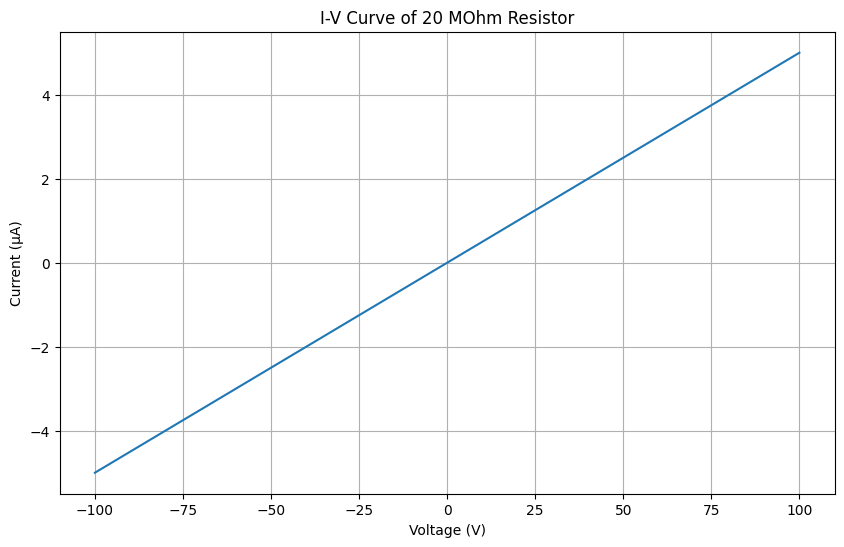

[-100  -98  -96  -94  -92  -90  -88  -86  -84  -82  -80  -78  -76  -74
  -72  -70  -68  -66  -64  -62  -60  -58  -56  -54  -52  -50  -48  -46
  -44  -42  -40  -38  -36  -34  -32  -30  -28  -26  -24  -22  -20  -18
  -16  -14  -12  -10   -8   -6   -4   -2    0    2    4    6    8   10
   12   14   16   18   20   22   24   26   28   30   32   34   36   38
   40   42   44   46   48   50   52   54   56   58   60   62   64   66
   68   70   72   74   76   78   80   82   84   86   88   90   92   94
   96   98  100]
[-5.0e-06 -4.9e-06 -4.8e-06 -4.7e-06 -4.6e-06 -4.5e-06 -4.4e-06 -4.3e-06
 -4.2e-06 -4.1e-06 -4.0e-06 -3.9e-06 -3.8e-06 -3.7e-06 -3.6e-06 -3.5e-06
 -3.4e-06 -3.3e-06 -3.2e-06 -3.1e-06 -3.0e-06 -2.9e-06 -2.8e-06 -2.7e-06
 -2.6e-06 -2.5e-06 -2.4e-06 -2.3e-06 -2.2e-06 -2.1e-06 -2.0e-06 -1.9e-06
 -1.8e-06 -1.7e-06 -1.6e-06 -1.5e-06 -1.4e-06 -1.3e-06 -1.2e-06 -1.1e-06
 -1.0e-06 -9.0e-07 -8.0e-07 -7.0e-07 -6.0e-07 -5.0e-07 -4.0e-07 -3.0e-07
 -2.0e-07 -1.0e-07  0.0e+00  1.0e-07  2.0e-07  3

/var/folders/13/rsw80g192f798gc60h4tz7k80000gn/T/ipykernel_11385/3166762055.py:60: RuntimeWarning: invalid value encountered in divide
  resistance = np.mean(np.abs(voltages / currents))


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from qcodes import Station, Measurement, initialise_or_create_database_at, new_experiment

# Initialize the database
initialise_or_create_database_at("./experiment_data.db")

# Create a new experiment
new_experiment(name="Keithley 6517A Staircase Sweep", sample_name="20 MOhm Resistor")

# Set up the station and instrument
station = Station()
keithley = MockKeithley6517A('keithley')
station.add_component(keithley)

# Configure the MockKeithley6517A
keithley.reset()
keithley.sense_function('current')

# Set up the staircase sweep
start_voltage = -100
stop_voltage = 100
step_voltage = 2
step_time = 0.1

keithley.stsweep_setup(start_voltage, step_voltage, stop_voltage, step_time)

# Create a measurement
meas = Measurement()

# Register parameters
meas.register_parameter(keithley.voltage)
meas.register_parameter(keithley.current, setpoints=(keithley.voltage,))

# Run the experiment
with meas.run() as datasaver:
    keithley.tseq_arm()
    keithley.initiate()
    
    # Fetch the data
    data = keithley.get_data()
    voltages = data['vsource']
    currents = data['reading']
    
    # Save the data
    for v, i in zip(voltages, currents):
        datasaver.add_result((keithley.voltage, v),
                             (keithley.current, i))

# Plot the results
plt.figure(figsize=(10,6))
plt.plot(voltages, currents * 1e6)  # Convert current to µA
plt.xlabel('Voltage (V)')
plt.ylabel('Current (µA)')
plt.title('I-V Curve of 20 MOhm Resistor')
plt.grid(True)
plt.show()

# Calculate and print the measured resistance
resistance = np.mean(np.abs(voltages / currents))
print(voltages)
print(currents)
print(f"Measured resistance: {resistance/1e6:.2f} MOhm")


In [3]:
voltages = np.array(voltages)
currents = np.array(currents)

# Avoid division by zero by masking out zero currents
mask = currents != 0
voltages_masked = voltages[mask]
currents_masked = currents[mask]

# Calculate resistance for each non-zero point
resistances = np.abs(voltages_masked / currents_masked)

# Calculate the mean resistance
resistance = np.mean(resistances)

print(f"Calculated resistance: {resistance:.2f} Ohm")

Calculated resistance: 20000000.00 Ohm
